In [1]:
pip install grip  

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.5/138.5 kB 1.6 MB/s eta 0:00:0031m1.1 MB/s eta 0:00:01
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=abdff8db492d17b54a0d808f5730bc3d4101baa6ddf52dd9d236b19f7d1b59b5
  Stored in directory: /Users/dakshmor/Library/Caches/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
  Created wheel for path-and-address: filename=path_and_address-2.0.1-py3-none-any.whl size=4062 sha256=adbeb29f86487a57eb5e4c79e263e67caa60ff6bbd9aca8c589ace97c87ca4dd
  Stored in directory: /Users/dakshmor/Library/Caches/pip/wheels/2c/81/2e/50746448073c3ac74647796ad9ca30ba837294d297b65b6cbd
Successfully built docopt path-and-address
Note: you may need to restart the kernel to use updated packages.


In [3]:
grip documentation_01.md

SyntaxError: invalid syntax (1973093632.py, line 1)

In [4]:
# this contains the code for information and more check the markdown file

In [6]:
import numpy as np
import pyvista as pv
from IPython.display import Image
import pyvista as pv
import numpy as np
import imageio.v3 as iio
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [46]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]

In [48]:
data = np.load("../data/mariel_betternot_and_retrograde.npy")[:,:1000,:] #eg data
def preprocesss(dat):
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  # Now (timesteps, 53, 3)
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    return data
data = preprocesss(data)

In [50]:

def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0

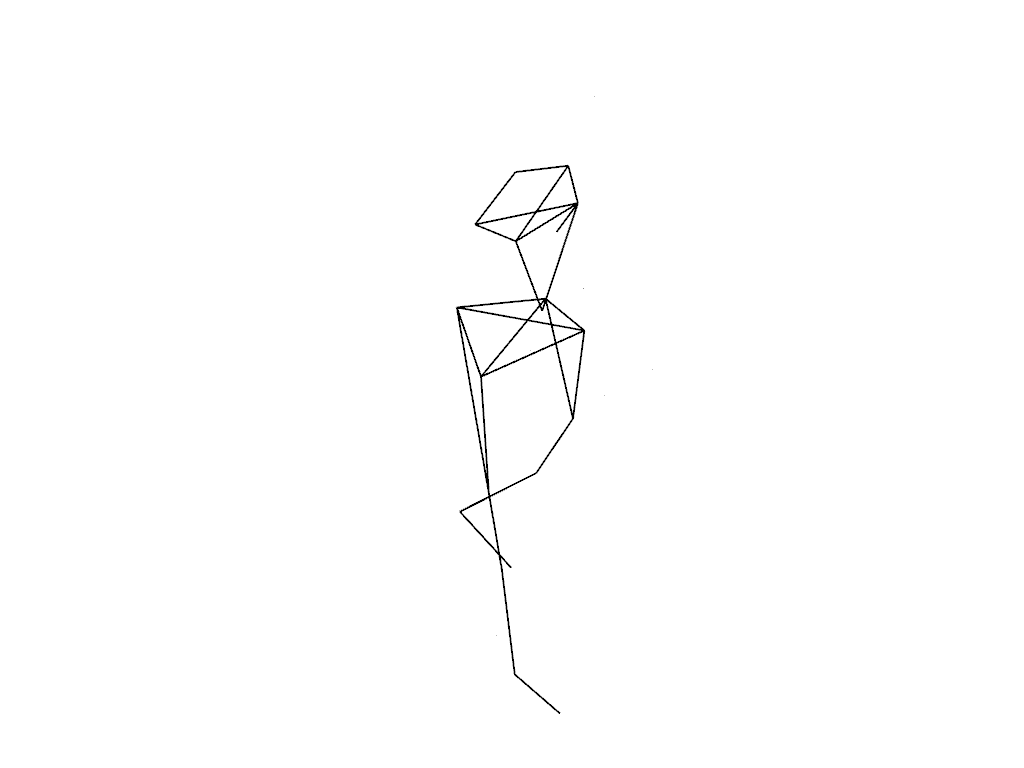

In [52]:
mesh, point_size = create_skeleton(data[0], point_labels, skeleton_lines,show_points=False,reduced_joint_names=reduced_joint_names)
plotter = pv.Plotter()
plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, 
                 point_size=point_size, render_points_as_spheres=True,color='black')
plotter.show()

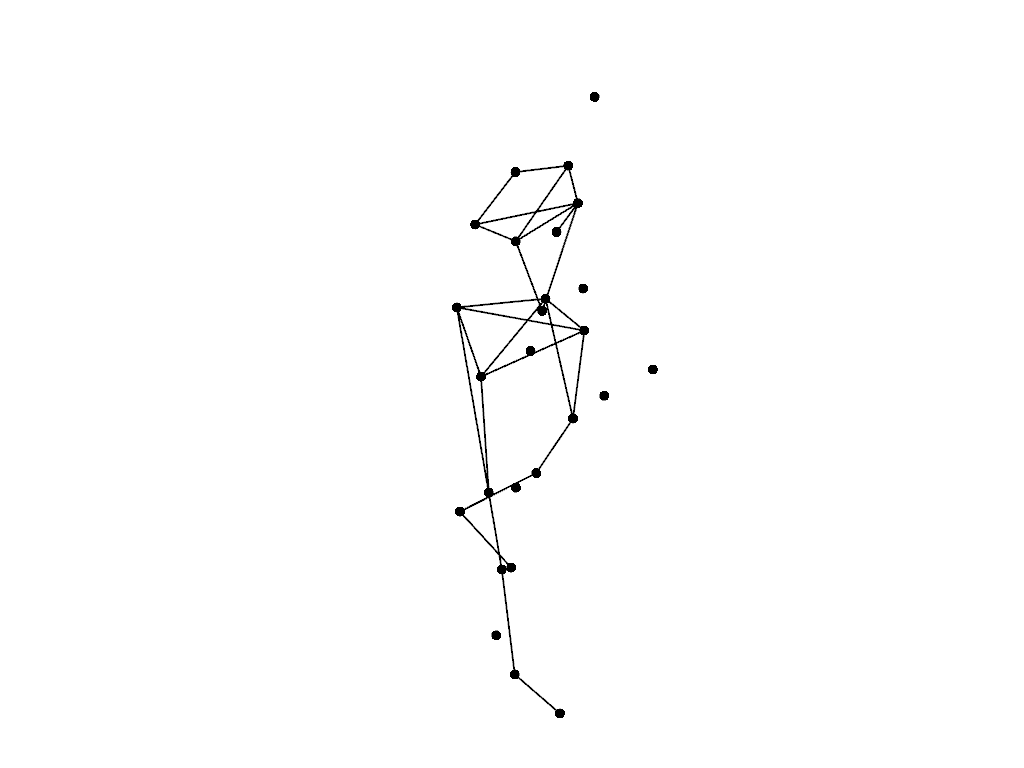

In [53]:
mesh, point_size = create_skeleton(data[0], point_labels, skeleton_lines,show_points=True,reduced_joint_names=reduced_joint_names)
plotter = pv.Plotter()
plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, 
                 point_size=point_size, render_points_as_spheres=True,color='black')
plotter.show()

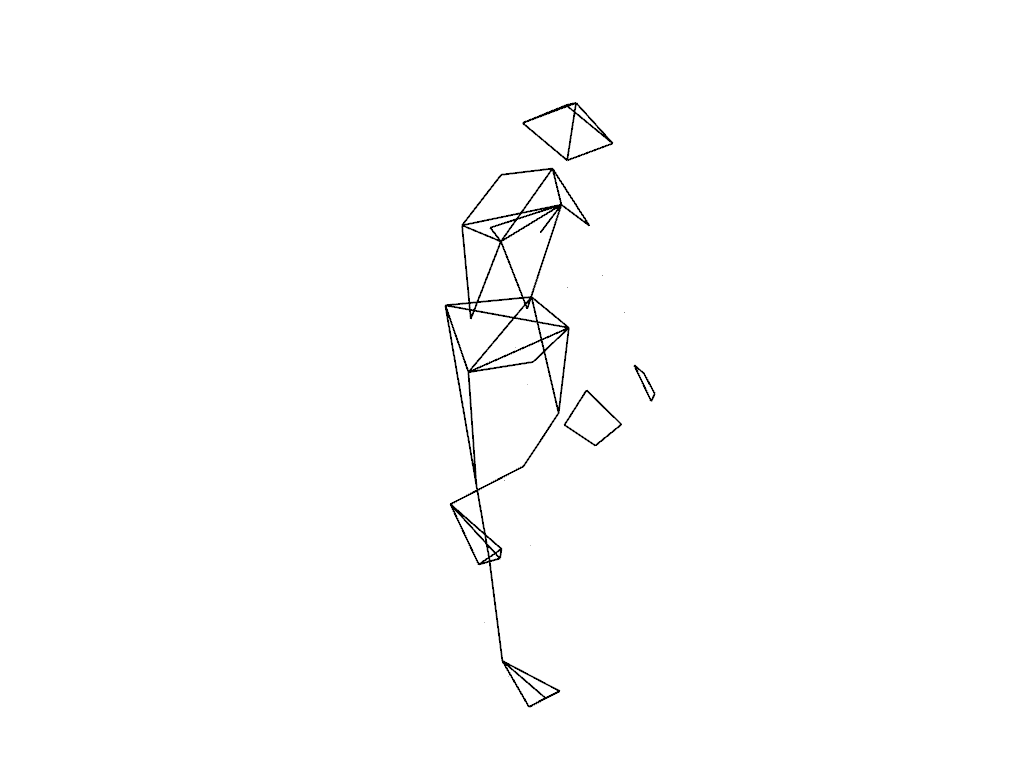

In [56]:
mesh, point_size = create_skeleton(data[0], point_labels, skeleton_lines,show_points=False)
plotter = pv.Plotter()
plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, 
                 point_size=point_size, render_points_as_spheres=True,color='black')
plotter.show()

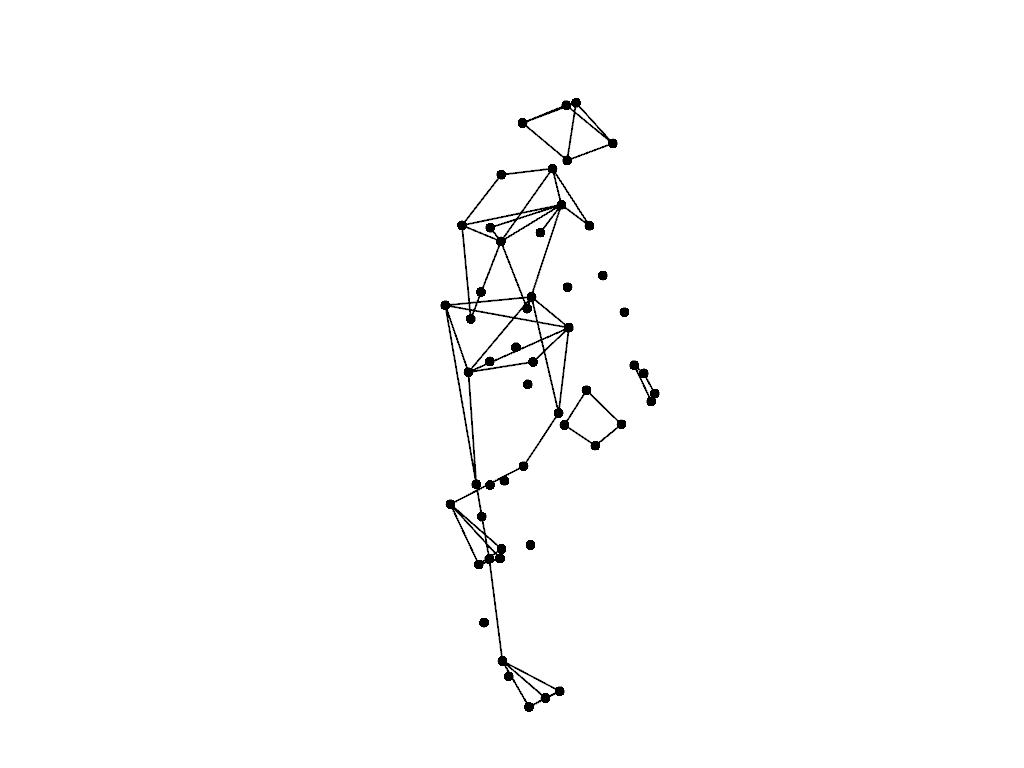

In [60]:
mesh, point_size = create_skeleton(data[0], point_labels, skeleton_lines,show_points=True)
plotter = pv.Plotter()
plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, 
                 point_size=point_size, render_points_as_spheres=True,color='black')
plotter.show()

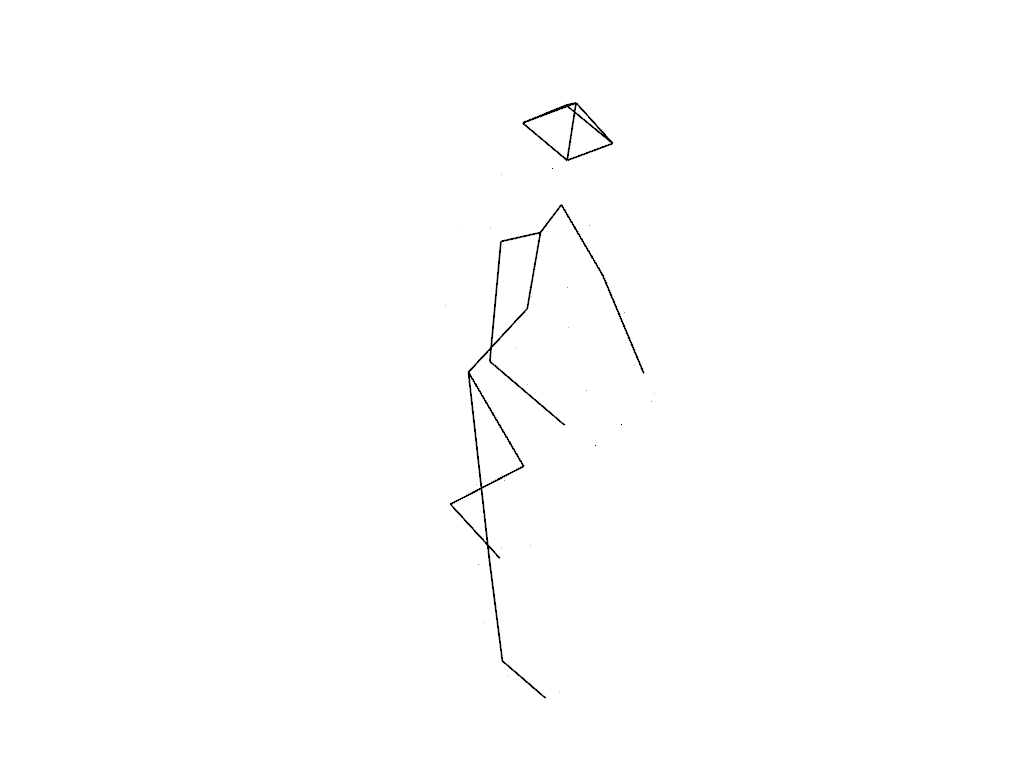

In [62]:
mesh, point_size = create_skeleton(data[0], point_labels, skeleton_lines2,show_points=False)
plotter = pv.Plotter()
plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, 
                 point_size=point_size, render_points_as_spheres=True,color='black')
plotter.show()

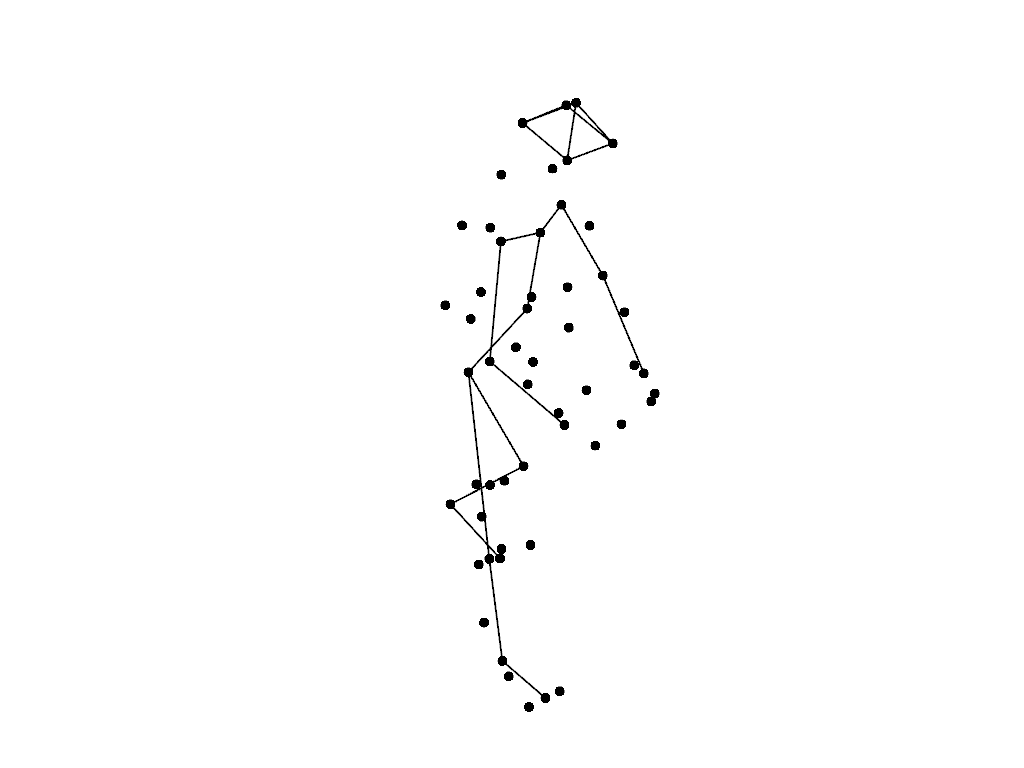

In [64]:
mesh, point_size = create_skeleton(data[0], point_labels, skeleton_lines2,show_points=True)
plotter = pv.Plotter()
plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, 
                 point_size=point_size, render_points_as_spheres=True,color='black')
plotter.show()

In [82]:
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 200:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines2, show_points=False)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                point_size=0
                point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(2.0) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")

In [84]:
# Now animating all the data 

In [86]:
import os
l =[]
for i,j,k in os.walk('../data'):
    l = k

In [88]:
file_list = l[1:]

In [90]:
file_list

['mariel_penelope.npy',
 'mariel_honey.npy',
 'mariel_beyond.npy',
 'mariel_betternot_and_retrograde.npy',
 'mariel_knownbetter.npy',
 'mariel_chunli.npy']

In [346]:
for file in file_list:
    print("Loading file:", file)
    file2=os.path.join('../data',file)
    file2 = np.load(file2)
    data = preprocesss(file2)
    filename = os.path.splitext(os.path.basename(file))[0]  
    path = os.path.join("animation", f"{filename}")
    generate_skeleton_animation(data, output_name=path, stride=1, fps=24)

Loading file: mariel_penelope.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:19<00:00, 78.00it/s]


Saved animation/mariel_penelope.gif and animation/mariel_penelope.mp4
Loading file: mariel_honey.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:21<00:00, 69.55it/s]


Saved animation/mariel_honey.gif and animation/mariel_honey.mp4
Loading file: mariel_beyond.npy


...

Saved animation/mariel_betternot_and_retrograde.gif and animation/mariel_betternot_and_retrograde.mp4
Loading file: mariel_knownbetter.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:18<00:00, 80.05it/s]


Saved animation/mariel_knownbetter.gif and animation/mariel_knownbetter.mp4
Loading file: mariel_chunli.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:19<00:00, 75.93it/s]


Saved animation/mariel_chunli.gif and animation/mariel_chunli.mp4


In [44]:
# Later in the realized the other simpler way to represent the figure after reading the pirounet paper So the type_2 animation contains that gif

In [92]:
for file in file_list:
    print("Loading file:", file)
    file2=os.path.join('../data',file)
    file2 = np.load(file2)
    data = preprocesss(file2)
    filename = os.path.splitext(os.path.basename(file))[0]+'_type2'  
    path = os.path.join("animation", f"{filename}")
    generate_skeleton_animation(data, output_name=path, stride=1, fps=24)

Loading file: mariel_penelope.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:17<00:00, 86.19it/s]


Saved animation/mariel_penelope_type2.gif and animation/mariel_penelope_type2.mp4
Loading file: mariel_honey.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:18<00:00, 81.03it/s]


Saved animation/mariel_honey_type2.gif and animation/mariel_honey_type2.mp4
Loading file: mariel_beyond.npy


...

Saved animation/mariel_betternot_and_retrograde_type2.gif and animation/mariel_betternot_and_retrograde_type2.mp4
Loading file: mariel_knownbetter.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:16<00:00, 90.49it/s]


Saved animation/mariel_knownbetter_type2.gif and animation/mariel_knownbetter_type2.mp4
Loading file: mariel_chunli.npy


100%|██████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:17<00:00, 85.36it/s]


Saved animation/mariel_chunli_type2.gif and animation/mariel_chunli_type2.mp4


In [95]:
data.shape

(4866, 53, 3)